In [6]:
import shap
import joblib
import pandas as pd
import matplotlib.pyplot as plt

model = joblib.load('../models/glucoseguard_model.pkl')
df = pd.read_csv('../data/diabetes_binary_health_indicators_BRFSS2015.csv', nrows=80000)

X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

# Use small sample for SHAP speed
X_sample = X.sample(500, random_state=42)

In [7]:
explainer = shap.LinearExplainer(model, X_sample)
shap_values = explainer.shap_values(X_sample)
print("SHAP values computed!")

Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


SHAP values computed!


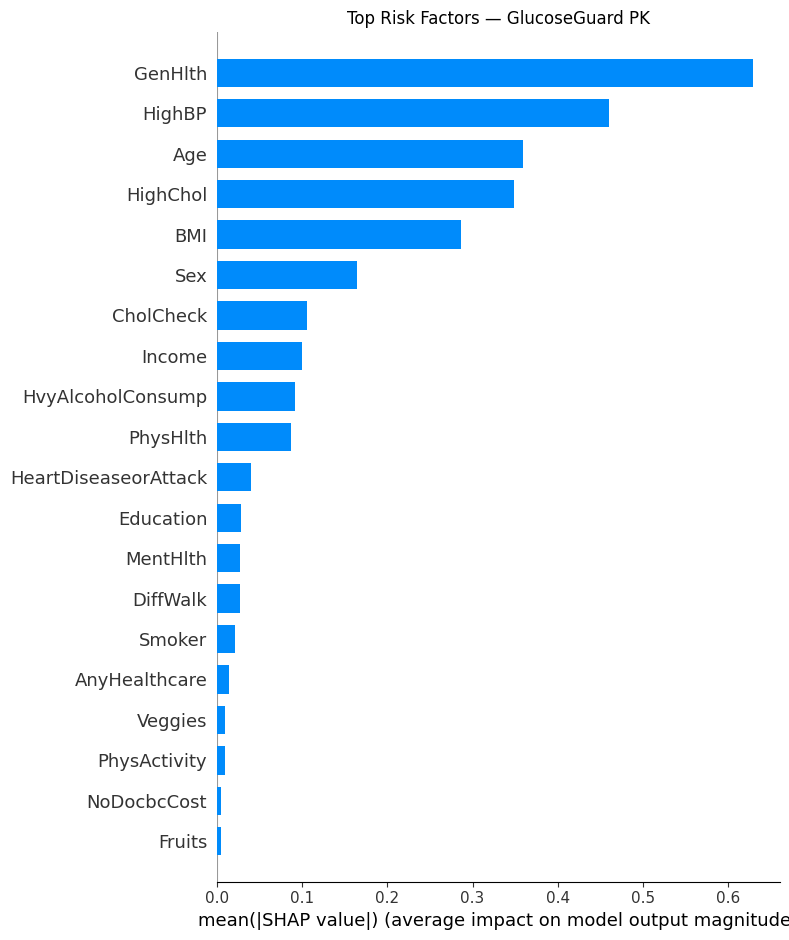

Saved!


In [8]:
shap.summary_plot(shap_values, X_sample, plot_type="bar", 
                  show=False)
plt.title("Top Risk Factors — GlucoseGuard PK")
plt.tight_layout()
plt.savefig('../models/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [9]:
joblib.dump(explainer, '../models/shap_explainer.pkl')
print("Explainer saved!")

Explainer saved!
